# 08 - Drift Mitigation

**Goal:** test simple, interpretable ways of making a classifier cope with sensor drift, using the leakage-safe time-aware framework.
All models use **default settings** (tuning did not help, notebook 07). Pipelines: `raw` (scaling only) and `LDA`.

> **Beginner note - four ways to fight drift**
> | Method | Idea | Needs labels from recent batches? | Uses the *unlabelled* readings of the test batch? |
> |---|---|---|---|
> | **Sliding window** | train only on the last *w* batches, forgetting old ones | yes | no |
> | **Recency weighting** | train on everything but give newer samples more weight (weight halves every *h* batches of age) | yes | no |
> | **Per-batch standardisation** | rescale every batch by its **own** mean and spread, so a shifted batch is re-centred | no | **yes** (feature statistics only) |
> | **CORAL** (correlation alignment) | re-colour the training features so their covariance matches the test batch | no | **yes** (feature statistics only) |
>
> The last two are **transductive**: they assume a whole batch of unlabelled readings is available (for example one day of sensor data) before predicting it.
> They never see the test labels. Our tests check that scrambling the test labels does not change any prediction.

**Declared before running (so settings cannot be cherry-picked):** the main settings are *window = 2 batches*, *half-life = 2 batches*, *CORAL regularisation = 1.0*.
Window 1 and 3 and half-life 1 are reported only as a sensitivity check. No setting was chosen by looking at test results.

**Protocols.** **P3** (rolling): for every test batch k = 2..10, train on batches 1..k-1 (then the method is applied). **P1**: train on batches 1-3, test on 4-10;
only the two unlabelled-target methods apply there because the training set is fixed.

In [1]:
import os, sys, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "16"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.mitigation import METHODS, MAIN_METHODS
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS, SEQ, DIV
apply_style()
FIG = ROOT / "results" / "figures"; RES = ROOT / "results"
res = pd.read_csv(RES / "08_mitigation_results.csv")
CONFIGS = [(m, v) for m in ["SVM", "kNN", "Random Forest", "Naive Bayes"] for v in ["raw", "LDA"]]
LABEL = {c: f"{c[0]} ({c[1]})" for c in CONFIGS}
print("rows:", len(res), "| protocols:", sorted(res.protocol.unique()), "| methods:", sorted(res.method.unique()))
print("main methods (declared in advance):", MAIN_METHODS)

rows: 780 | protocols: ['P1', 'P3'] | methods: ['baseline', 'batch-std', 'coral', 'recency-h1', 'recency-h2', 'window-1', 'window-2', 'window-2 + batch-std', 'window-3']
main methods (declared in advance): ['window-2', 'recency-h2', 'batch-std', 'coral']


## 0. Sanity check: the `baseline` method is exactly the earlier evaluation

The `baseline` rows (no mitigation) must reproduce the default-setting results of notebook 04.

In [2]:
b4 = pd.read_csv(RES / "04_baselines_results.csv")
chk = res[(res.method == "baseline")].merge(b4[["model", "variant", "protocol", "test_batch", "macro_f1"]], on=["model", "variant", "protocol", "test_batch"], suffixes=("", "_04"))
print(f"compared {len(chk)} rows; largest difference in macro-F1: {(chk.macro_f1 - chk.macro_f1_04).abs().max():.2e}")

compared 128 rows; largest difference in macro-F1: 0.00e+00


## 1. Rolling protocol P3: does mitigation beat plain retraining on all history?

Mean macro-F1 over test batches 2-10 for each method, and the **change relative to the baseline** (orange = better, blue = worse). `n/a` = not applicable
(kNN cannot use sample weights).

method                 baseline  window-1  window-2  window-3  recency-h1  recency-h2  batch-std  coral  window-2 + batch-std
model         variant                                                                                                        
SVM           raw         0.797     0.652     0.717     0.782       0.777       0.785      0.733  0.615                 0.695
              LDA         0.756     0.636     0.687     0.724       0.758       0.754      0.693  0.732                 0.570
kNN           raw         0.766     0.644     0.674     0.740         NaN         NaN      0.668  0.537                 0.614
              LDA         0.779     0.657     0.724     0.761         NaN         NaN      0.688  0.741                 0.624
Random Forest raw         0.774     0.675     0.698     0.747       0.756       0.756      0.652  0.514                 0.622
              LDA         0.763     0.557     0.659     0.704       0.759       0.762      0.705  0.679                 0.572
Naive Bayes   raw         0.504     0.424     0.488     0.540       0.517       0.511      0.496  0.416                 0.444
              LDA         0.783     0.640     0.695     0.764       0.777       0.784      0.693  0.746                 0.600

Number of the 9 test batches on which the method beats the baseline:


,window-1,window-2,window-3,recency-h1,recency-h2,batch-std,coral,window-2 + batch-std
SVM (raw),1,1,1,2.0,4.0,1,1,2
SVM (LDA),1,0,0,4.0,4.0,1,3,0
kNN (raw),0,2,1,NaN,NaN,3,1,3
kNN (LDA),0,1,2,NaN,NaN,1,3,1
Random Forest (raw),1,2,2,3.0,3.0,1,0,2
Random Forest (LDA),0,1,1,3.0,3.0,4,1,1
Naive Bayes (raw),4,4,6,6.0,5.0,4,2,3
Naive Bayes (LDA),0,1,2,2.0,2.0,0,4,1


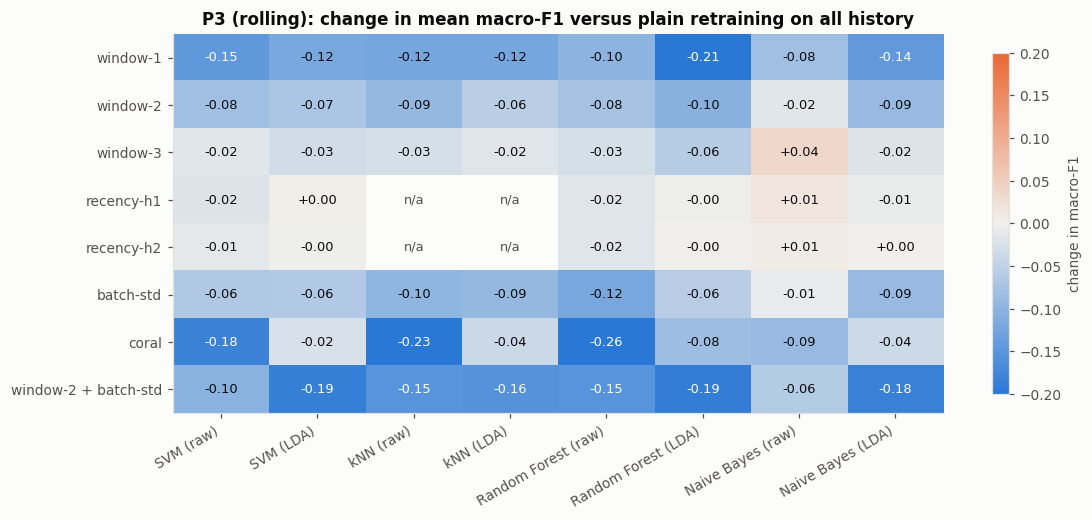

In [3]:
p3 = res[res.protocol == "P3"]
m3 = p3.groupby(["model", "variant", "method"]).macro_f1.mean().unstack("method")[list(METHODS)]
m3 = m3.loc[CONFIGS]; m3.to_csv(RES / "08_p3_mean_macro_f1.csv")
d3 = m3.sub(m3["baseline"], axis=0).drop(columns="baseline"); d3.to_csv(RES / "08_p3_delta_vs_baseline.csv")
pd.set_option("display.width", 220); display(m3.round(3))

piv = p3.pivot_table(index=["model", "variant", "method"], columns="test_batch", values="macro_f1")
base = piv.xs("baseline", level="method")
wins = pd.DataFrame({meth: [int((piv.loc[(m, v, meth)] > base.loc[(m, v)] + 1e-12).sum()) if (m, v, meth) in piv.index else np.nan for (m, v) in CONFIGS]
                     for meth in d3.columns}, index=[LABEL[c] for c in CONFIGS])
wins.to_csv(RES / "08_p3_wins_out_of_9.csv"); print("Number of the 9 test batches on which the method beats the baseline:"); display(wins)

fig, ax = plt.subplots(figsize=(10.5, 4.8)); A = d3.T.values.astype(float)
im = ax.imshow(np.ma.masked_invalid(A), cmap=DIV, vmin=-0.2, vmax=0.2, aspect="auto"); ax.grid(False)
ax.set_xticks(range(len(CONFIGS))); ax.set_xticklabels([LABEL[c] for c in CONFIGS], rotation=30, ha="right"); ax.set_yticks(range(A.shape[0])); ax.set_yticklabels(d3.columns)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        v = A[i, j]; ax.text(j, i, "n/a" if np.isnan(v) else f"{v:+.2f}", ha="center", va="center", fontsize=8.5, color=INK2 if np.isnan(v) else ("white" if abs(v) > 0.14 else INK))
ax.set_title("P3 (rolling): change in mean macro-F1 versus plain retraining on all history")
fig.colorbar(im, ax=ax, label="change in macro-F1", shrink=0.9); fig.tight_layout(); fig.savefig(FIG / "30_mitigation_p3_delta.png"); plt.show()

## 2. Fixed training set P1: the two methods that need no labels

Train on batches 1-3 only. Per-batch standardisation and CORAL use the unlabelled readings of each test batch.

macro_f1                  accuracy                 
method                baseline batch-std  coral baseline batch-std  coral
model         variant                                                    
SVM           raw        0.690     0.659  0.525    0.705     0.707  0.566
              LDA        0.614     0.467  0.631    0.666     0.500  0.698
kNN           raw        0.609     0.614  0.464    0.615     0.646  0.506
              LDA        0.610     0.522  0.623    0.640     0.561  0.642
Random Forest raw        0.518     0.559  0.426    0.573     0.624  0.471
              LDA        0.625     0.514  0.622    0.647     0.551  0.652
Naive Bayes   raw        0.461     0.506  0.330    0.506     0.556  0.394
              LDA        0.621     0.526  0.626    0.632     0.572  0.656

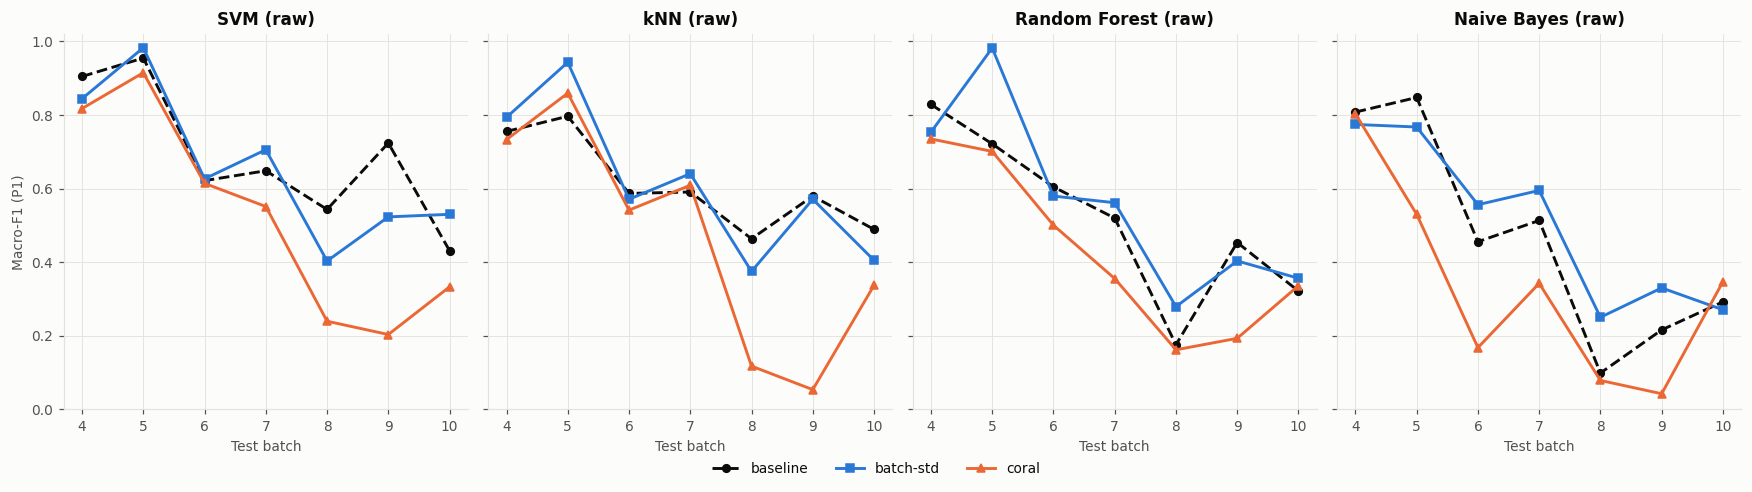

In [4]:
p1 = res[res.protocol == "P1"]
m1 = p1.groupby(["model", "variant", "method"]).agg(macro_f1=("macro_f1", "mean"), accuracy=("accuracy", "mean")).unstack("method")
m1 = m1.loc[CONFIGS]; m1.to_csv(RES / "08_p1_summary.csv"); display(m1.round(3))

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3), sharey=True)
cols = {"baseline": INK, "batch-std": SERIES[0], "coral": SERIES[1]}; mk = {"baseline": "o", "batch-std": "s", "coral": "^"}
for ax, model in zip(axes, ["SVM", "kNN", "Random Forest", "Naive Bayes"]):
    for meth in ["baseline", "batch-std", "coral"]:
        d = p1[(p1.model == model) & (p1.variant == "raw") & (p1.method == meth)]
        ax.plot(d.test_batch, d.macro_f1, color=cols[meth], marker=mk[meth], ms=5, lw=1.9, ls="--" if meth == "baseline" else "-", label=meth)
    ax.set_title(f"{model} (raw)"); ax.set_xlabel("Test batch"); ax.set_xticks(range(4, 11)); ax.set_ylim(0, 1.02)
axes[0].set_ylabel("Macro-F1 (P1)"); h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04)); fig.tight_layout(); fig.savefig(FIG / "31_mitigation_p1_per_batch.png"); plt.show()

## 3. Batch by batch under rolling retraining (SVM, scaling only)

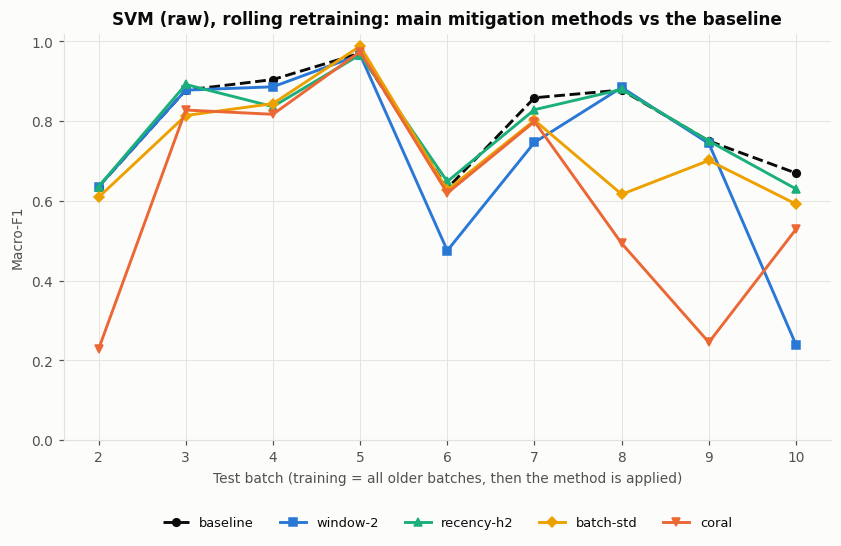

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
sty = {"baseline": (INK, "--", "o"), "window-2": (SERIES[0], "-", "s"), "recency-h2": (SERIES[2], "-", "^"), "batch-std": (SERIES[3], "-", "D"), "coral": (SERIES[1], "-", "v")}
for meth, (c, ls, m) in sty.items():
    d = p3[(p3.model == "SVM") & (p3.variant == "raw") & (p3.method == meth)]
    ax.plot(d.test_batch, d.macro_f1, color=c, ls=ls, marker=m, ms=5, lw=1.9, label=meth)
ax.set_xlabel("Test batch (training = all older batches, then the method is applied)"); ax.set_ylabel("Macro-F1"); ax.set_ylim(0, 1.02); ax.set_xticks(range(2, 11))
ax.set_title("SVM (raw), rolling retraining: main mitigation methods vs the baseline")
ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=5); fig.savefig(FIG / "32_mitigation_svm_per_batch.png"); plt.show()

## 4. Sensitivity: window size and half-life (descriptive, not used to pick a setting)

In [6]:
sens = m3[["baseline", "window-1", "window-2", "window-3", "recency-h1", "recency-h2"]].copy(); sens.index = [LABEL[c] for c in CONFIGS]
sens.to_csv(RES / "08_p3_sensitivity.csv"); display(sens.round(3))

method,baseline,window-1,window-2,window-3,recency-h1,recency-h2
SVM (raw),0.797,0.652,0.717,0.782,0.777,0.785
SVM (LDA),0.756,0.636,0.687,0.724,0.758,0.754
kNN (raw),0.766,0.644,0.674,0.740,NaN,NaN
kNN (LDA),0.779,0.657,0.724,0.761,NaN,NaN
Random Forest (raw),0.774,0.675,0.698,0.747,0.756,0.756
Random Forest (LDA),0.763,0.557,0.659,0.704,0.759,0.762
Naive Bayes (raw),0.504,0.424,0.488,0.540,0.517,0.511
Naive Bayes (LDA),0.783,0.640,0.695,0.764,0.777,0.784


## 5. The Toluene check

Toluene is present only in batches 1, 2 and 6-10. A short window can contain **no Toluene at all** (for example the last two batches before batch 6 are batches 4 and 5),
which makes Toluene impossible to predict by construction. To keep that from being mistaken for a drift effect we also report **macro-F1 over gases 1-5**
(Toluene removed from the average) and the Toluene recall on batches that contain it.

In [7]:
t = p3[(p3.model == "SVM") & (p3.variant == "raw")]
summary = t.groupby("method").agg(macro_f1_all=("macro_f1", "mean"), macro_f1_gases1to5=("macro_f1_gases1to5", "mean")).loc[list(METHODS)]
tol = t[t.test_batch >= 6].groupby("method").agg(toluene_recall_B6_10=("toluene_recall", "mean"))
tr_in = t[t.test_batch >= 6].groupby("method").toluene_in_train.mean().rename("mean_toluene_samples_in_training_B6_10")
summary = summary.join(tol).join(tr_in); summary.to_csv(RES / "08_toluene_check_svm_raw_P3.csv"); display(summary.round(3))
print("Toluene samples in the training window, SVM raw, by test batch:")
display(t[t.method.isin(["baseline", "window-1", "window-2", "window-3"])].pivot(index="method", columns="test_batch", values="toluene_in_train").loc[["baseline", "window-1", "window-2", "window-3"]])

,macro_f1_all,macro_f1_gases1to5,toluene_recall_B6_10,mean_toluene_samples_in_training_B6_10
method,,,,
baseline,0.797,0.829,0.469,820.8
window-1,0.652,0.667,0.392,230.8
window-2,0.717,0.753,0.290,441.4
window-3,0.782,0.815,0.431,648.4
recency-h1,0.777,0.812,0.465,820.8
recency-h2,0.785,0.818,0.479,820.8
batch-std,0.733,0.790,0.138,820.8
coral,0.615,0.643,0.308,820.8
window-2 + batch-std,0.695,0.730,0.339,441.4


Toluene samples in the training window, SVM raw, by test batch:


test_batch,2,3,4,5,6,7,8,9,10
method,,,,,,,,,
baseline,74,79,79,79,79,546,1114,1132,1233
window-1,74,5,0,0,0,467,568,18,101
window-2,74,79,5,0,0,467,1035,586,119
window-3,74,79,79,5,0,467,1035,1053,687


## 6. Key takeaways

All models use default settings. Mitigation settings were declared before running (window 2, half-life 2, CORAL regularisation 1.0). Window 1 and 3 and half-life 1 are sensitivity checks only.

**Rolling protocol P3, SVM with scaling only (mean macro-F1 over test batches 2-10)**

| Method | Macro-F1 | Change vs baseline |
|---|---|---|
| Baseline: retrain on all older batches | **79.7%** | - |
| Recency weighting, half-life 2 | 78.5% | -1.2 |
| Sliding window, 3 batches | 78.2% | -1.6 |
| Per-batch standardisation | 73.3% | -6.5 |
| Sliding window, 2 batches | 71.7% | -8.0 |
| Window 2 + per-batch standardisation | 69.5% | -10.2 |
| Sliding window, 1 batch | 65.2% | -14.6 |
| CORAL | 61.5% | -18.3 |

1. **None of the mitigation methods beat simply retraining on all available history.** Averaged over the 8 model/pipeline combinations (6 for recency, since kNN cannot use sample weights), the change in macro-F1 relative to the baseline is: window 1 batch **-0.130**, window 2 **-0.073**, window 3 **-0.020**, recency half-life 1 **-0.006**, half-life 2 **-0.004**, per-batch standardisation **-0.074**, CORAL **-0.118**, window 2 + per-batch standardisation **-0.148**. The only gains are small and on weak baselines (Naive Bayes on raw features: window 3 +0.036, recency +0.013 and +0.007, while its baseline is only 50.4%).
2. **More history beats fresher history here.** The penalty shrinks as the window grows (window 1, 2, 3 batches: -0.130, -0.073, -0.020), and recency weighting, which keeps all the data but down-weights old samples, is practically neutral. Much of the window penalty comes from tiny training sets: batches 4, 5, 8 and 9 hold only 161 to 470 samples, so for example the 2-batch window has just 358 training samples for test batch 6 and 764 for batch 10, and the SVM falls to 47.5% and 23.9% macro-F1 there (baseline 63.2% and 67.0%). Across all combinations the mean penalty is -0.133 when the window has fewer than 500 training samples and -0.036 when it has 1,500 or more.
3. **The Toluene confound does not explain it.** With Toluene removed from the average, the penalties are essentially unchanged (window 1, 2, 3: -0.133, -0.074, -0.016; per-batch standardisation -0.061; CORAL -0.122). Short windows do lose Toluene training samples (SVM Toluene recall on batches 6-10: baseline 46.9%, window 2 29.0%, per-batch standardisation 13.8%), but the loss on the other gases is just as large.
4. **Fixed training set P1 (train B1-3): the methods that need no labels give mixed, mostly negative results.** Nothing beats the default SVM (69.0% macro-F1, 70.5% accuracy).
   * *Per-batch standardisation* helps some raw-feature models: Random Forest 51.8% to 55.9% (accuracy 57.3% to 62.4%), Naive Bayes 46.1% to 50.6% (50.6% to 55.6%), kNN 60.9% to 61.4% (61.5% to 64.6%); SVM drops from 69.0% to 65.9% macro-F1 with unchanged accuracy (70.5% to 70.7%). With LDA it hurts every model by 9 to 15 points (SVM 61.4% to 46.7%, kNN 61.0% to 52.2%, Random Forest 62.5% to 51.4%, Naive Bayes 62.1% to 52.6%). It beats the baseline in only 19 of the 56 model/pipeline/batch cells.
   * *CORAL* cuts raw-feature models sharply (SVM 69.0% to 52.5%, kNN 60.9% to 46.4%, Random Forest 51.8% to 42.6%, Naive Bayes 46.1% to 33.0%) and leaves LDA models roughly unchanged (-0.3 to +1.7 points). It beats the baseline in only 20 of 56 cells, and it hurt most on the small batches 8 and 9 (-0.09 and -0.18 on average) and was neutral on the largest, batch 10 (+0.005).
5. **Why the unlabelled-target methods may fail (hypotheses, not tested here).** (a) Batches differ in **gas mix and concentration**, so a per-batch mean or covariance mixes up drift with composition; (b) CORAL estimates a 128 x 128 covariance from as few as 161 samples, which fits its larger losses on the small batches 8 and 9. Both need dedicated experiments; why LDA pipelines react so differently from raw-feature ones is not yet understood.
6. **Implications.** In this benchmark, a strong, honest baseline (retrain on everything, default SVM) is very hard to beat with simple drift-compensation tricks, and a short training window is actively harmful because the batches are small. This agrees with the tuning result: the accuracy lost to drift is not recovered by simple knobs. The remaining ideas worth testing are **gas-aware** methods (alignment within each gas rather than across the whole batch, which needs labels or confident pseudo-labels), per-sensor or per-feature-type compensation, and the feature-level interpretability analysis planned next.
7. **Caveats.** Default-setting models, four model families, two pipelines, one declared setting per method; some test batches are small, so single-batch differences are noisy (no significance tests yet). A negative result for these specific, simple methods is not a statement about all drift compensation.